In [5]:
import importlib
import src.dataset
importlib.reload(src.dataset)
from src.dataset import FetalPlaneDataset

In [6]:
import sys
sys.path.append("..")

from src.dataset import FetalPlaneDataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

dataset = FetalPlaneDataset(
    csv_path="../data/FETAL_PLANES_DB_data.csv",
    images_dir="../data/Images",
    train=True,
    transform=transform
)

print("Training samples:", len(dataset))
image, label = dataset[0]
print("Image shape:", image.shape)
print("Label:", label)

Training samples: 7129
Image shape: torch.Size([1, 128, 128])
Label: Other


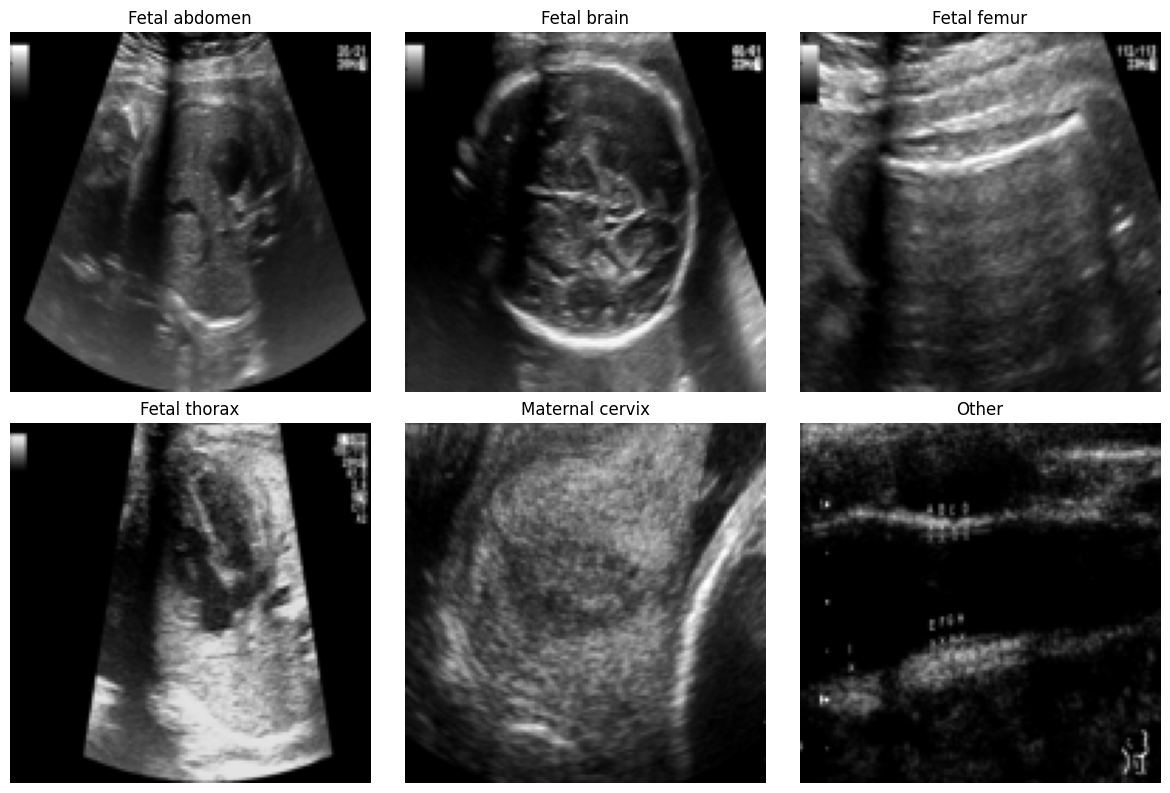

In [7]:
import matplotlib.pyplot as plt

# get one image from each class
classes = ["Fetal abdomen", "Fetal brain", "Fetal femur",
           "Fetal thorax", "Maternal cervix", "Other"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, plane in enumerate(classes):
    # find first image of this class
    for j in range(len(dataset)):
        img, label = dataset[j]
        if label == plane:
            axes[i].imshow(img.squeeze().numpy(), cmap='gray')
            axes[i].set_title(plane)
            axes[i].axis('off')
            break

plt.tight_layout()
plt.show()

In [8]:
# Class distribution
print("=== Class distribution ===")
print(dataset.data["Plane"].value_counts())
print()

# Images per patient
print("=== Images per patient (first 10) ===")
print(dataset.data["Patient_num"].value_counts().head(10))
print()

# Ultrasound machines
print("=== Ultrasound machines ===")
print(dataset.data["US_Machine"].value_counts())
print()

=== Class distribution ===
Plane
Other              2601
Fetal brain        1620
Fetal thorax       1058
Maternal cervix     981
Fetal femur         516
Fetal abdomen       353
Name: count, dtype: int64

=== Images per patient (first 10) ===
Patient_num
792    88
789    80
790    63
793    62
830    62
43     55
771    51
795    51
835    48
39     47
Name: count, dtype: int64

=== Ultrasound machines ===
US_Machine
Voluson E6     3456
Aloka          3377
Other           285
Voluson S10      11
Name: count, dtype: int64



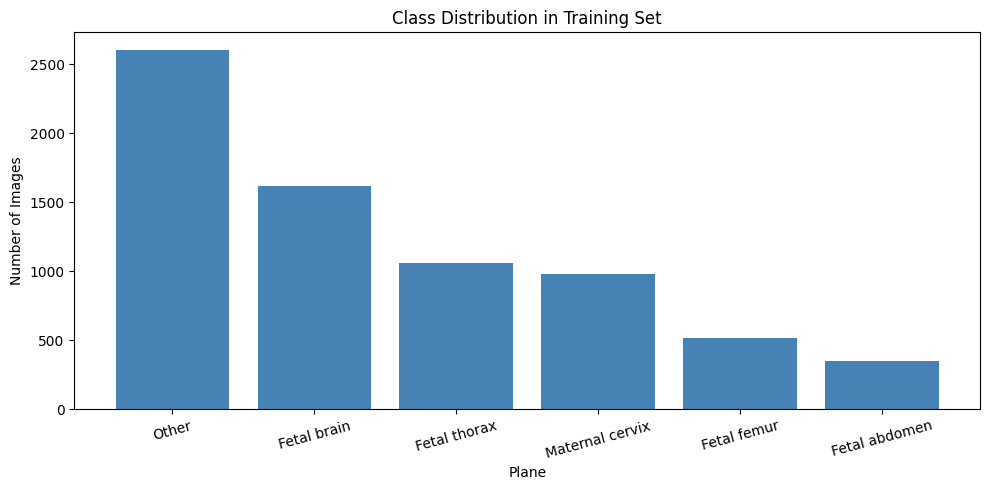

=== Class percentages ===
Other               : 2601 (36.5%)
Fetal brain         : 1620 (22.7%)
Fetal thorax        : 1058 (14.8%)
Maternal cervix     :  981 (13.8%)
Fetal femur         :  516 (7.2%)
Fetal abdomen       :  353 (5.0%)


In [9]:
import matplotlib.pyplot as plt

class_counts = dataset.data["Plane"].value_counts()

plt.figure(figsize = (10, 5))
plt.bar(class_counts.index, class_counts.values, color = "steelblue")
plt.title("Class Distribution in Training Set")
plt.xlabel("Plane")
plt.ylabel("Number of Images")
plt.xticks(rotation = 15)
plt.tight_layout()
plt.show()

# print percentages
print("=== Class percentages ===")
total = class_counts.sum()
for plane, count in class_counts.items():
    print(f"{plane:20s}: {count:4d} ({100 * count / total:.1f}%)")

In [10]:
import importlib
import src.model
importlib.reload(src.model)
from src.model import AutoEncoder

model = AutoEncoder(in_channels = 1, latent_channels = 16)
print(model)

# test with a dummy input
import torch
x = torch.randn(1, 1, 128, 128)
output = model(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

code = model.encode(x)
print("Latent shape:", code.shape)

AutoEncoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(128, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): ConvTranspose2d(16, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): ConvTranspo

Using device: cuda


Epoch 1 / 20: 100%|██████████| 56/56 [00:37<00:00,  1.50it/s, loss=0.0088] 


Epoch 1 / 20 - avg loss:  0.023826


Epoch 2 / 20: 100%|██████████| 56/56 [00:37<00:00,  1.50it/s, loss=0.0049] 


Epoch 2 / 20 - avg loss:  0.006328


...

Epoch 18 / 20 - avg loss:  0.002015


Epoch 19 / 20: 100%|██████████| 56/56 [00:37<00:00,  1.50it/s, loss=0.00197]


Epoch 19 / 20 - avg loss:  0.001967


Epoch 20 / 20: 100%|██████████| 56/56 [00:36<00:00,  1.51it/s, loss=0.002]  


Epoch 20 / 20 - avg loss:  0.001997


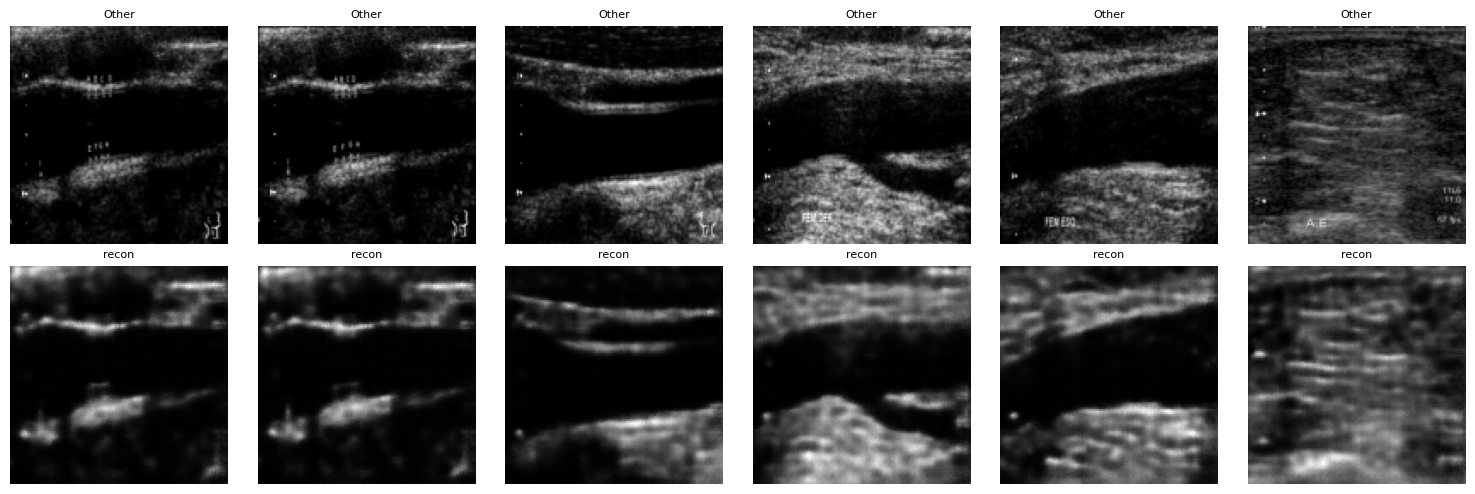

In [12]:
import importlib
import src.train
importlib.reload(src.train)
from src.train import train, visualise_reconstructions
from torch.utils.data import DataLoader

# setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# dataloader
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0)

# model
model = AutoEncoder(in_channels=1, latent_channels=16)

# train for just 3 epochs to test everything works
losses = train(model, loader, num_epochs=20, device=device)

# visualise
visualise_reconstructions(model, dataset, device=device)

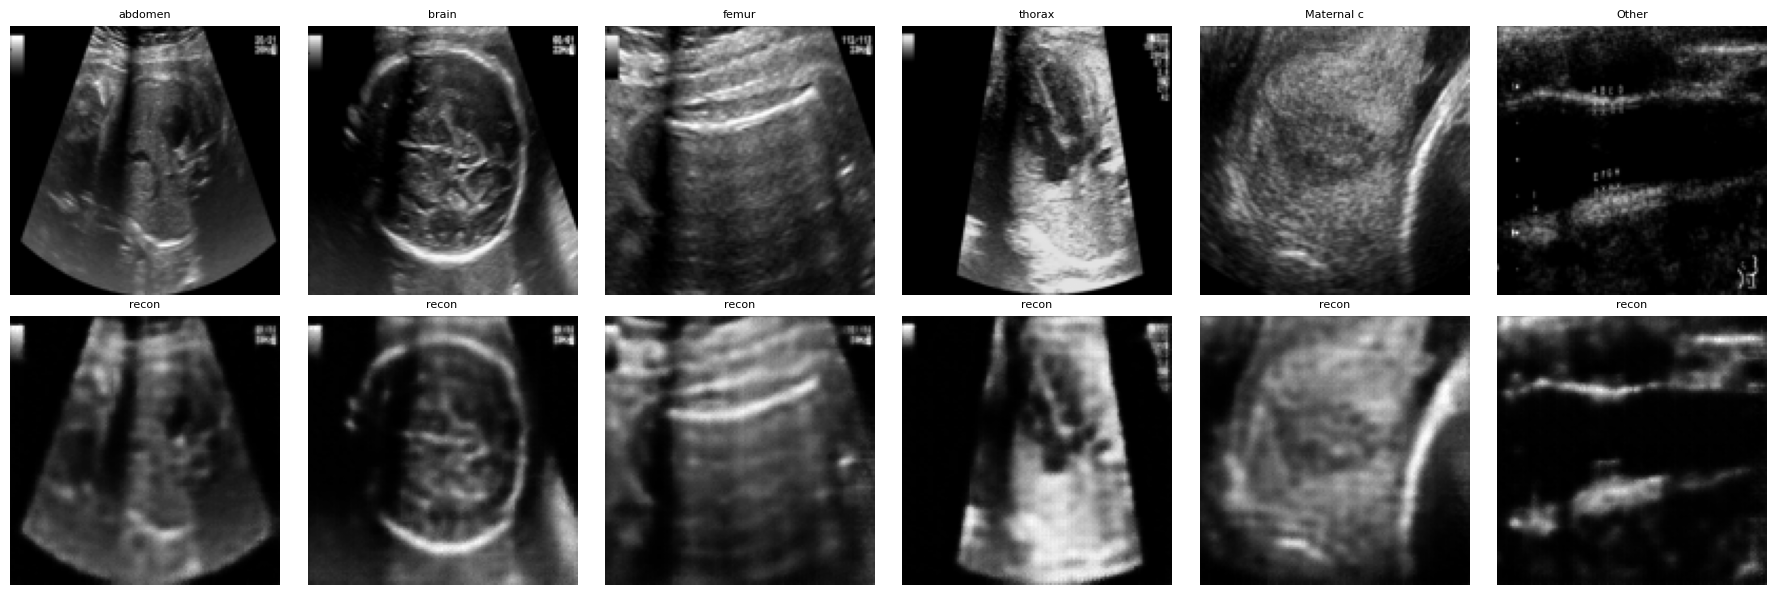

In [17]:
importlib.reload(src.train)
from src.train import train, visualise_reconstructions

visualise_reconstructions(model, dataset, device=device)